In [1]:
!sudo apt-get -qq update
!sudo apt-get -qq install -y fonts-nanum
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/nanum: skipping, looped dire

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams["font.family"] = "NanumGothic"
mpl.rcParams["axes.unicode_minus"] = False
mpl.rcParams["figure.autolayout"] = True

print("✅ 한글 폰트 적용 완료")


✅ 한글 폰트 적용 완료


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/nanum: skipping, looped dire

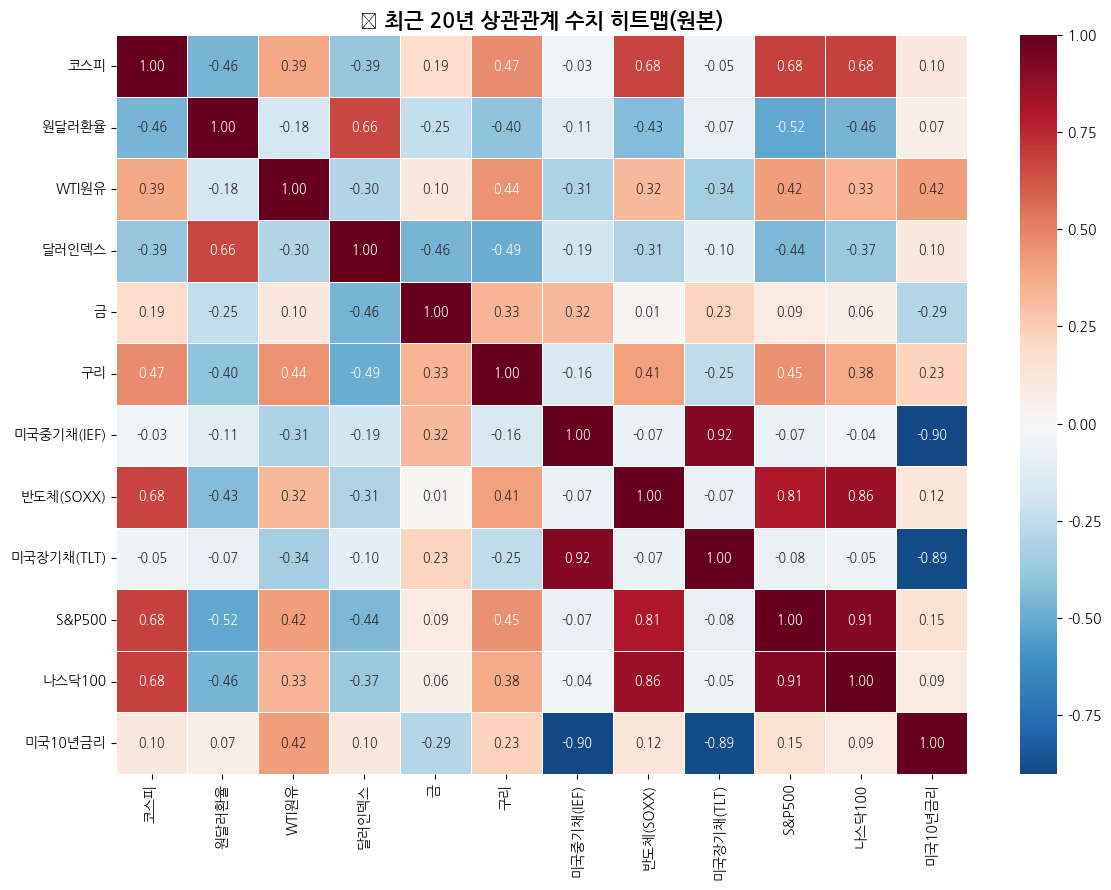

🖼️ PNG 저장 완료 → output_dashboard/히트맵_상관관계_클러스터정렬_20년.png


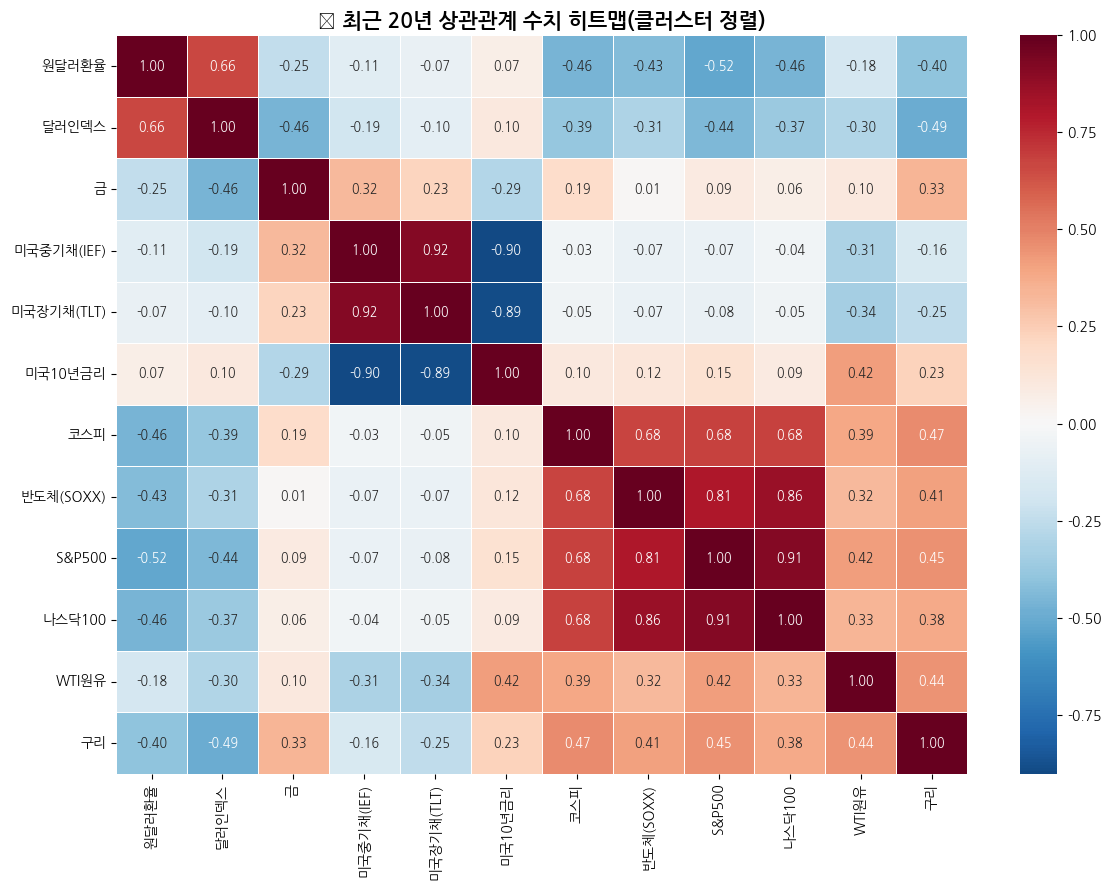


[최근 20년 분석 요약]
- S&P500과 가장 반대로 움직이는 자산: 원달러환율 (-0.52)
- 분산효과 우수 자산 TOP 5: 미국중기채(IEF), 미국장기채(TLT), 금, 미국10년금리, WTI원유
--------------------------------------------------------------------------------
📁 엑셀 저장 완료 → output_dashboard/상관관계_대시보드_20년.xlsx
🖼️ PNG 저장 완료 → output_dashboard/히트맵_상관관계_원본_10년.png


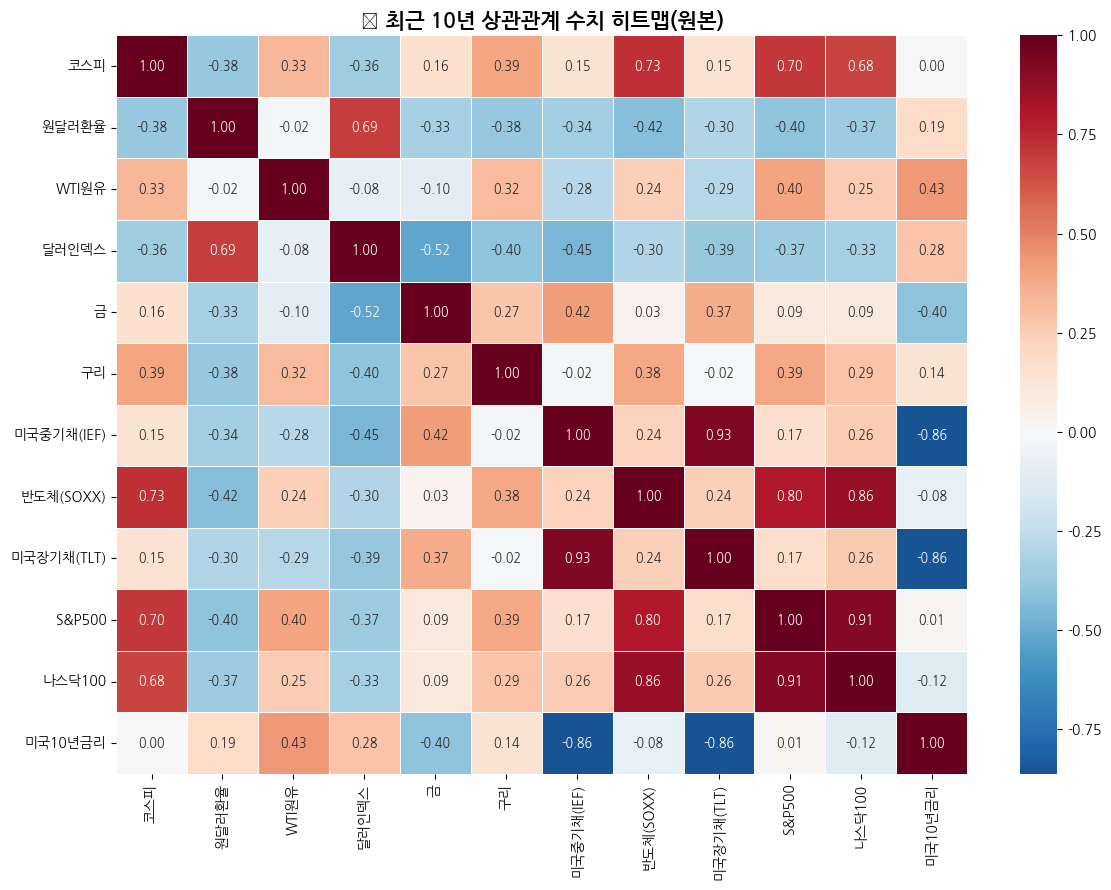

🖼️ PNG 저장 완료 → output_dashboard/히트맵_상관관계_클러스터정렬_10년.png


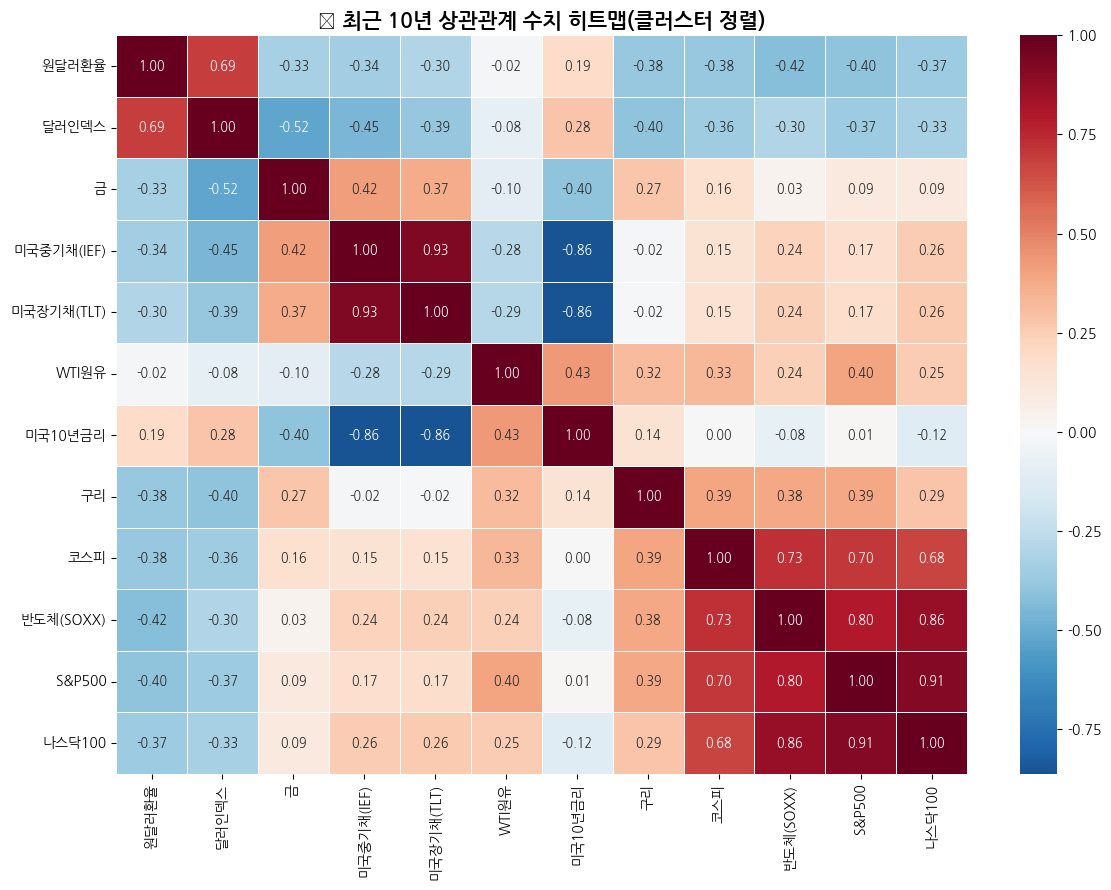


[최근 10년 분석 요약]
- S&P500과 가장 반대로 움직이는 자산: 원달러환율 (-0.40)
- 분산효과 우수 자산 TOP 5: 미국10년금리, 금, 미국중기채(IEF), 미국장기채(TLT), WTI원유
--------------------------------------------------------------------------------
📁 엑셀 저장 완료 → output_dashboard/상관관계_대시보드_10년.xlsx
🖼️ PNG 저장 완료 → output_dashboard/히트맵_상관관계_원본_5년.png


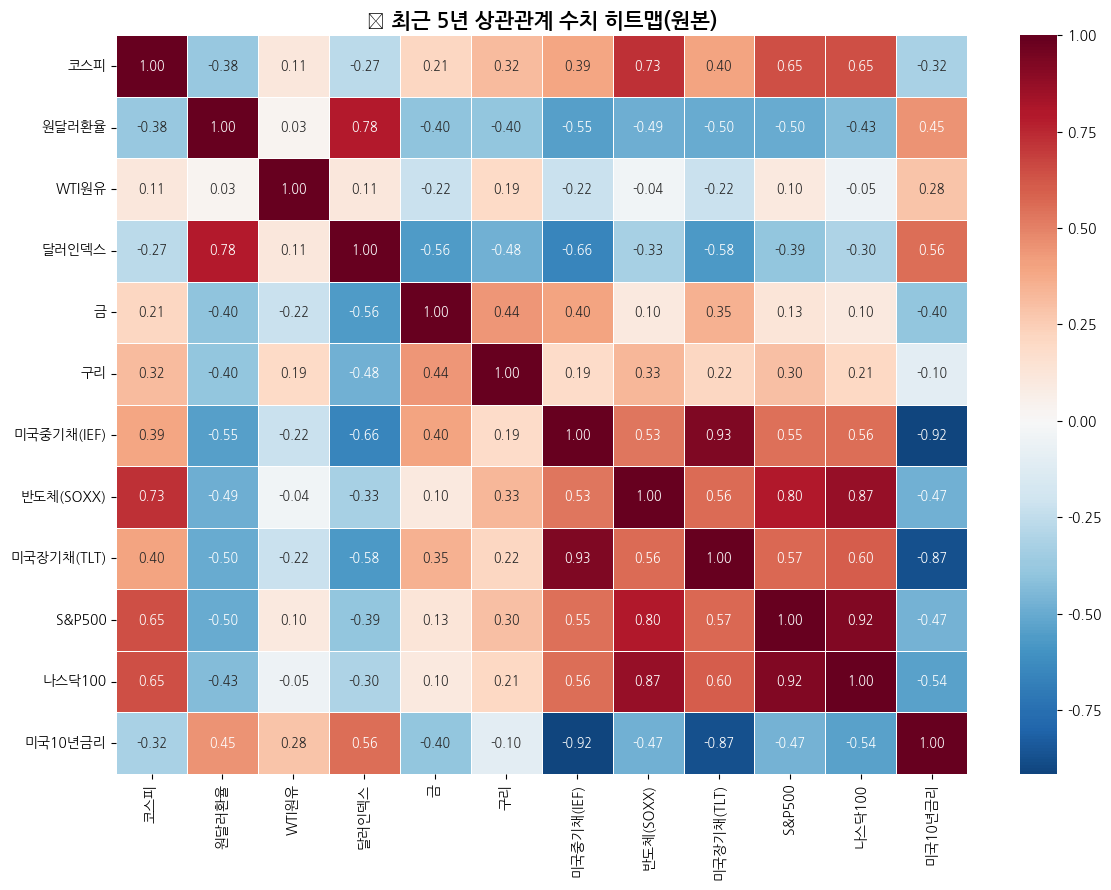

🖼️ PNG 저장 완료 → output_dashboard/히트맵_상관관계_클러스터정렬_5년.png


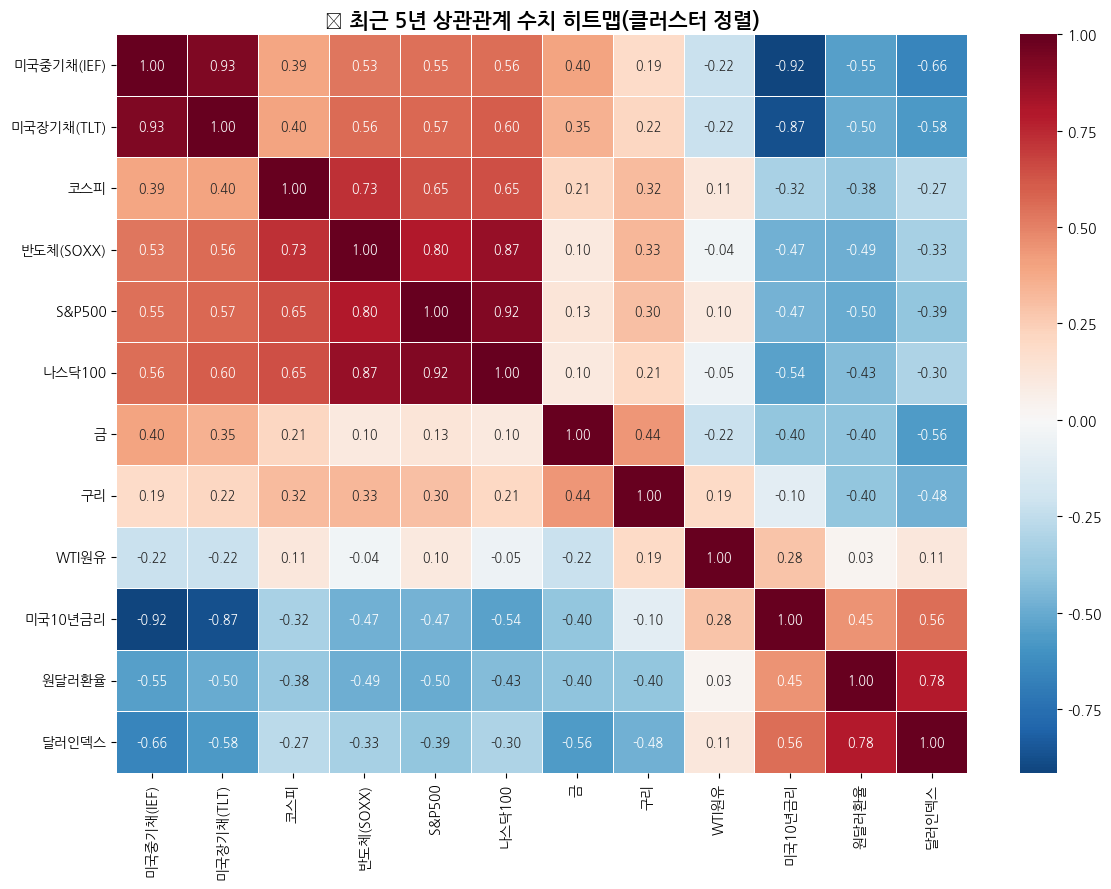


[최근 5년 분석 요약]
- S&P500과 가장 반대로 움직이는 자산: 원달러환율 (-0.50)
- 분산효과 우수 자산 TOP 5: WTI원유, 금, 구리, 달러인덱스, 원달러환율
--------------------------------------------------------------------------------
📁 엑셀 저장 완료 → output_dashboard/상관관계_대시보드_5년.xlsx
🖼️ PNG 저장 완료 → output_dashboard/매크로_상대강도_대시보드.png


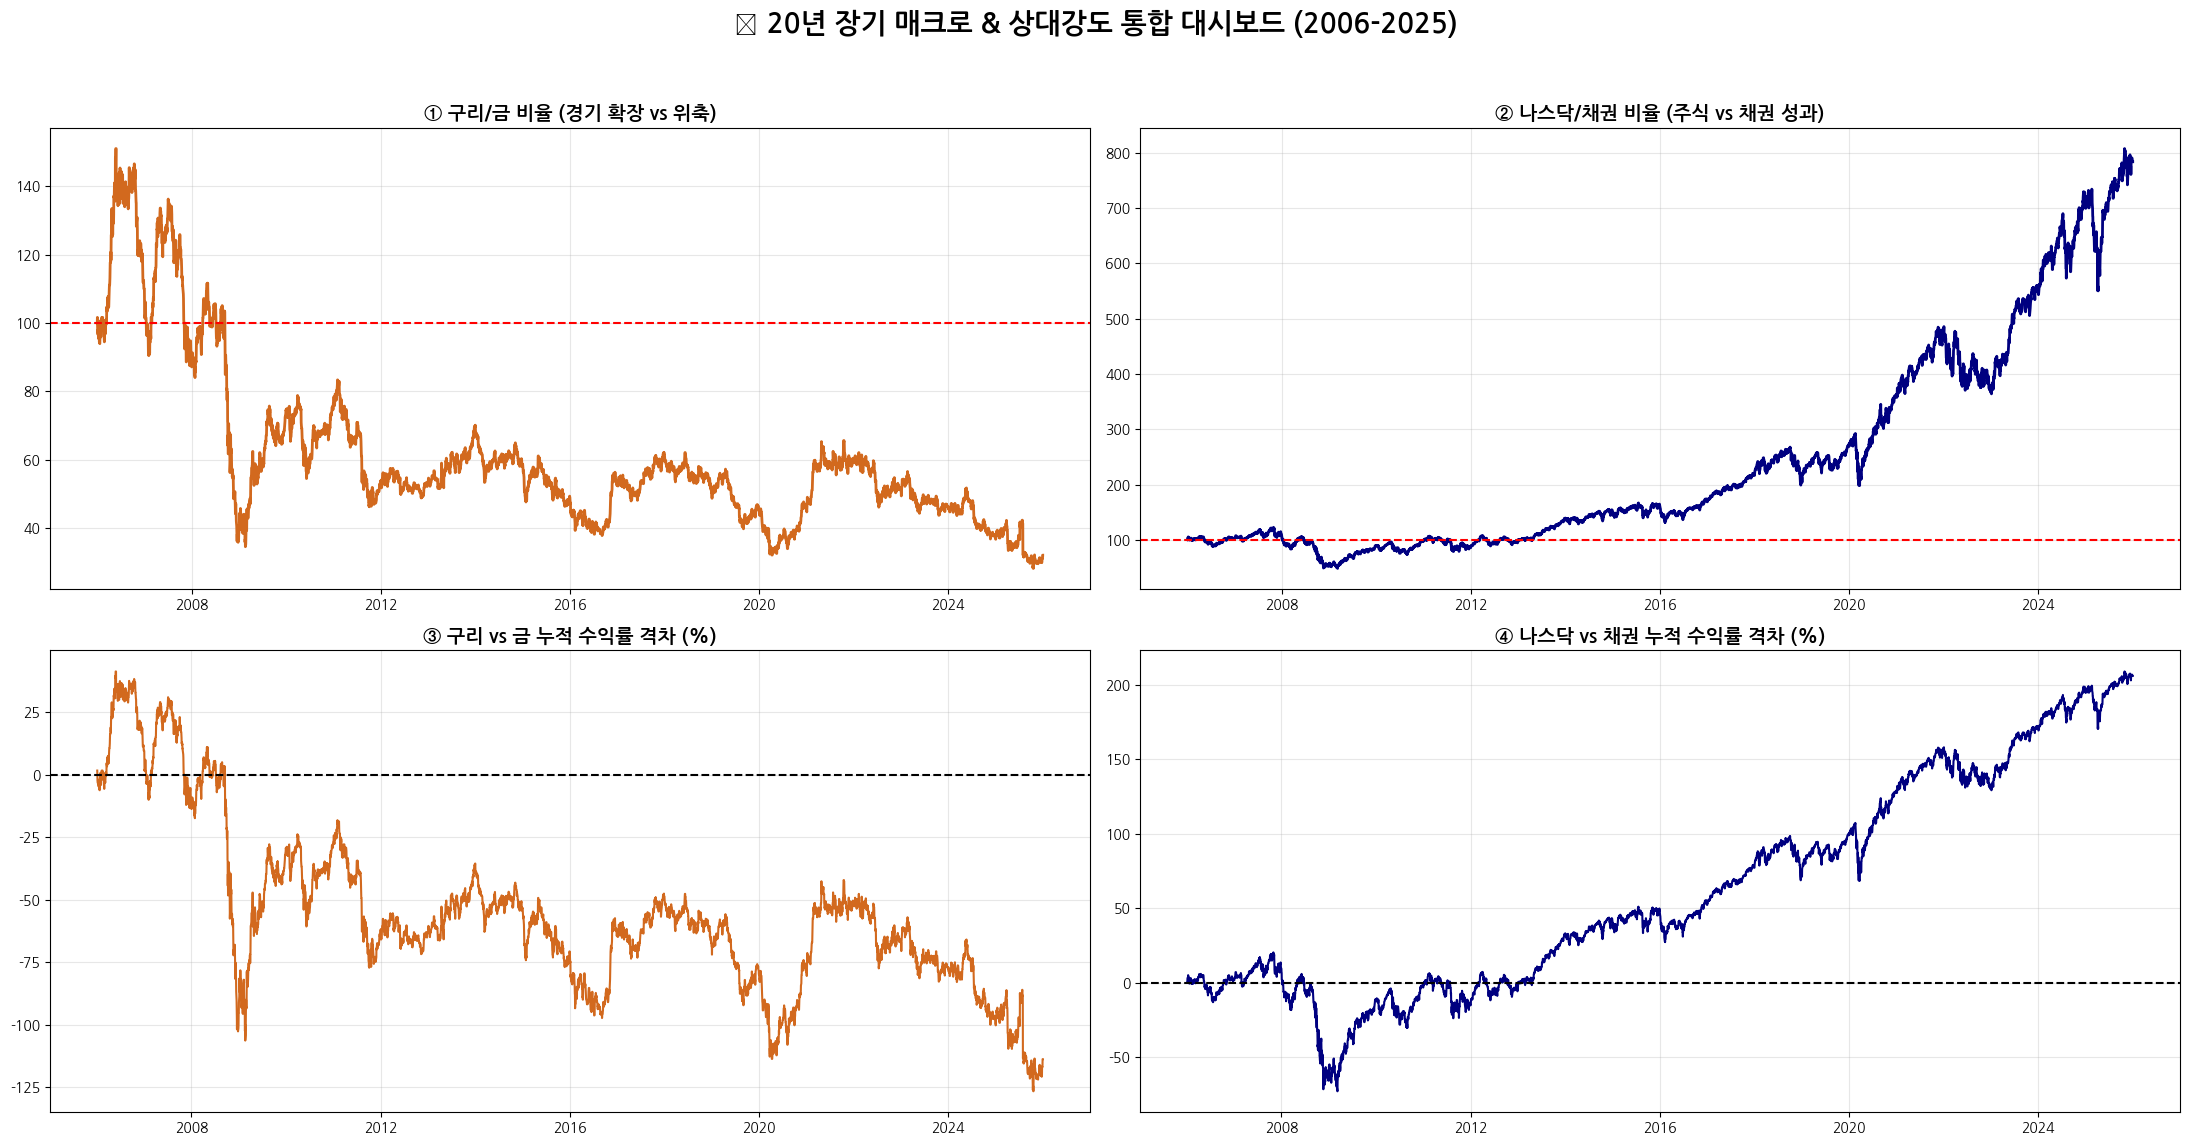

📁 엑셀 저장 완료 → output_dashboard/매크로_상대강도_대시보드.xlsx

✅ 완료! 저장된 파일 확인 방법
1) Colab 왼쪽 파일탐색기 → output_dashboard 폴더
2) 엑셀(.xlsx) + 이미지(.png) 모두 저장됨


In [3]:
# =============================================================================
# [올인원 최종] 20년/10년/5년 기간별 "수치 히트맵" + 매크로 상대강도 대시보드
# + (기간별) 엑셀 저장 + (기간별) PNG 이미지 저장 + 한글화
# =============================================================================

# 1) 설치
!pip install -q yfinance finance-datareader pandas numpy matplotlib seaborn scipy xlsxwriter

# 2) 한글 폰트(Colab)
!sudo apt-get -qq update
!sudo apt-get -qq install -y fonts-nanum
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib

import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import yfinance as yf
import FinanceDataReader as fdr
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

# Re-import matplotlib and seaborn AFTER font installation and cache clearing
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# Rebuild font cache and set font
# fm._rebuild() # This line is removed as _rebuild() is deprecated or not available
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

print("✅ 환경 설정 및 한글화 완료")

# -----------------------------------------------------------------------------
# 0) 저장 폴더 생성
# -----------------------------------------------------------------------------
OUT_DIR = "output_dashboard"
os.makedirs(OUT_DIR, exist_ok=True)
print(f"📁 저장 폴더: {OUT_DIR}")

# -----------------------------------------------------------------------------
# 1) 데이터 로딩 (2006-01-01 ~ 2025-12-31)
# -----------------------------------------------------------------------------
종료일 = "2025-12-31"
시작일 = "2006-01-01"

print(f"📥 전 기간 데이터를 통합 수집 중입니다...")

full_tickers_map = {
    "S&P500": "^GSPC",
    "나스닥100": "^NDX",
    "코스피": "KS11",
    "구리": "HG=F",
    "금": "GC=F",
    "WTI원유": "CL=F",
    "달러인덱스": "DX-Y.NYB",
    "원달러환율": "USD/KRW",
    "미국10년금리": "^TNX",
    "미국장기채(TLT)": "TLT",
    "미국중기채(IEF)": "IEF",
    "반도체(SOXX)": "SOXX",
}

raw_list = []
yfinance_tickers_map = {}
fdr_tickers_map = {}

for name, tk in full_tickers_map.items():
    if tk in ["KS11", "USD/KRW"]:
        fdr_tickers_map[name] = tk
    else:
        yfinance_tickers_map[name] = tk

# FDR 로드
for name, tk in fdr_tickers_map.items():
    try:
        s = fdr.DataReader(tk, 시작일, 종료일)["Close"]
        s.name = name
        raw_list.append(s)
    except Exception as e:
        print(f"⚠️ {name}({tk}) 로딩 실패: {e} -> 제외")

# yfinance 로드(한 번에)
if yfinance_tickers_map:
    try:
        yf_symbols = list(yfinance_tickers_map.values())
        yf_data = yf.download(yf_symbols, start=시작일, end=종료일, progress=False)

        if isinstance(yf_data.columns, pd.MultiIndex):
            df_yf_close = yf_data["Close"].copy()
        else:
            df_yf_close = yf_data[["Close"]].copy()
            if len(yf_symbols) == 1:
                df_yf_close.rename(columns={"Close": yf_symbols[0]}, inplace=True)

        reverse_yf_map = {v: k for k, v in yfinance_tickers_map.items()}
        df_yf_close.rename(columns=reverse_yf_map, inplace=True)

        for col in df_yf_close.columns:
            s = df_yf_close[col].dropna()
            if s.empty:
                continue
            s.name = col
            raw_list.append(s)

    except Exception as e:
        print(f"⚠️ yfinance 로딩 에러: {e} -> yfinance 자산 제외")

print(f"\n✅ 로드 성공: {[s.name for s in raw_list]}")

df_all = pd.concat(raw_list, axis=1).ffill().dropna()
print(f"✅ 데이터 정제 완료: {len(df_all)}일 / 컬럼 {df_all.shape[1]}개")
print(f"✅ 최종 컬럼: {df_all.columns.tolist()}")

# -----------------------------------------------------------------------------
# 2) 저장 함수(엑셀/이미지)
# -----------------------------------------------------------------------------
def save_excel_period(years, corr_raw, corr_sorted, top_df, logret_df):
    fname = os.path.join(OUT_DIR, f"상관관계_대시보드_{years}년.xlsx")
    with pd.ExcelWriter(fname, engine="xlsxwriter") as writer:
        corr_raw.round(4).to_excel(writer, sheet_name="상관관계_원본")
        corr_sorted.round(4).to_excel(writer, sheet_name="상관관계_클러스터정렬")
        if top_df is not None and len(top_df) > 0:
            top_df.to_excel(writer, sheet_name="TOP_분산후보", index=True)
        logret_df.round(6).to_excel(writer, sheet_name="월봉_로그수익률")
    print(f"📁 엑셀 저장 완료 → {fname}")

def save_excel_macro(rs_df):
    fname = os.path.join(OUT_DIR, "매크로_상대강도_대시보드.xlsx")
    with pd.ExcelWriter(fname, engine="xlsxwriter") as writer:
        rs_df.round(4).to_excel(writer, sheet_name="상대강도_시계열")
    print(f"📁 엑셀 저장 완료 → {fname}")

def save_png(fig, filename):
    path = os.path.join(OUT_DIR, filename)
    fig.savefig(path, dpi=220, bbox_inches="tight")
    print(f"🖼️ PNG 저장 완료 → {path}")

# -----------------------------------------------------------------------------
# 3) 기간별 분석(히트맵 수치화 + TOP)
# -----------------------------------------------------------------------------
def analyze_period(years):
    target_date = f"{2026-years}-01-01"
    df_p = df_all[df_all.index >= target_date].copy()

    # 월봉 로그수익률
    월봉 = df_p.resample("M").last()
    로그수익률 = np.log(월봉 / 월봉.shift(1)).dropna()

    if 로그수익률.empty or 로그수익률.shape[1] < 2:
        print(f"⚠️ 최근 {years}년: 로그수익률 데이터 부족 -> 스킵")
        return None, None, None, None

    상관 = 로그수익률.corr()
    상관 = 상관.replace([np.inf, -np.inf], np.nan).dropna(axis=0, how="any").dropna(axis=1, how="any")
    if 상관.empty or 상관.shape[0] < 2:
        print(f"⚠️ 최근 {years}년: 상관 계산 자산 부족 -> 스킵")
        return None, None, None, None

    # 클러스터 정렬
    dist = ((1 - 상관) / 2).clip(0, 1).fillna(0)
    Z = linkage(squareform(dist.values, checks=False), method="average")
    order = leaves_list(Z)
    상관_정렬 = 상관.iloc[order, order]

    # (A) 히트맵(원본 상관) - 수치화
    fig1 = plt.figure(figsize=(12, 9))
    sns.heatmap(상관, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
                linewidths=0.5, annot_kws={"size": 9})
    plt.title(f"🔥 최근 {years}년 상관관계 수치 히트맵(원본)", fontsize=15, fontweight="bold")
    plt.tight_layout()
    save_png(fig1, f"히트맵_상관관계_원본_{years}년.png")
    plt.show()

    # (B) 히트맵(클러스터 정렬) - 수치화
    fig2 = plt.figure(figsize=(12, 9))
    sns.heatmap(상관_정렬, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
                linewidths=0.5, annot_kws={"size": 9})
    plt.title(f"🔥 최근 {years}년 상관관계 수치 히트맵(클러스터 정렬)", fontsize=15, fontweight="bold")
    plt.tight_layout()
    save_png(fig2, f"히트맵_상관관계_클러스터정렬_{years}년.png")
    plt.show()

    # TOP 후보(주식 기준 평균상관 낮은 순)
    TOP = None
    주식기준_원본 = ["S&P500", "나스닥100"]
    주식기준 = [c for c in 주식기준_원본 if c in 상관.columns]

    if 주식기준:
        편입후보 = [c for c in 상관.columns if c not in 주식기준]
        if 편입후보:
            상관도 = 상관.loc[편입후보, 주식기준].mean(axis=1)
            TOP = pd.DataFrame({
                "주식상관계수": 상관도,
                "절대상관": 상관도.abs(),
                "연수익": 로그수익률[편입후보].mean() * 12,
                "연변동": 로그수익률[편입후보].std() * np.sqrt(12)
            }).sort_values("절대상관").head(10)

            print(f"\n[최근 {years}년 분석 요약]")
            if "S&P500" in 상관.columns:
                print(f"- S&P500과 가장 반대로 움직이는 자산: {상관['S&P500'].idxmin()} ({상관['S&P500'].min():.2f})")
            print(f"- 분산효과 우수 자산 TOP 5: {', '.join(TOP.index[:5].tolist())}")
            print("-" * 80)

    return 상관, 상관_정렬, TOP, 로그수익률

# -----------------------------------------------------------------------------
# 4) 20년 / 10년 / 5년 실행 + 저장(엑셀 + PNG)
# -----------------------------------------------------------------------------
print("\n" + "="*90)
print("【 기간별 상관관계 분석 실행 (20년, 10년, 5년) 】")
print("="*90)

for yr in [20, 10, 5]:
    corr_raw, corr_sorted, top_df, logret = analyze_period(yr)
    if corr_raw is not None:
        save_excel_period(yr, corr_raw, corr_sorted, top_df, logret)

# -----------------------------------------------------------------------------
# 5) 매크로 상대강도 대시보드 + 저장(PNG + 엑셀)
# -----------------------------------------------------------------------------
required_macro_cols = ["구리", "금", "나스닥100", "미국중기채(IEF)", "미국10년금리"]
missing_macro_cols = [c for c in required_macro_cols if c not in df_all.columns]

if missing_macro_cols:
    print(f"\n⚠️ 매크로 대시보드 스킵(필수 컬럼 부족): {missing_macro_cols}")
else:
    norm = (df_all / df_all.iloc[0]) * 100
    구리금_비율 = (norm["구리"] / norm["금"]) * 100
    나스닥채권_비율 = (norm["나스닥100"] / norm["미국중기채(IEF)"]) * 100
    구리금_로그차이 = (np.log(df_all["구리"]).diff() - np.log(df_all["금"]).diff()).cumsum() * 100
    나스닥채권_로그차이 = (np.log(df_all["나스닥100"]).diff() - np.log(df_all["미국중기채(IEF)"]).diff()).cumsum() * 100

    fig, axes = plt.subplots(2, 2, figsize=(22, 12))
    fig.suptitle("📊 20년 장기 매크로 & 상대강도 통합 대시보드 (2006-2025)", fontsize=20, fontweight="bold")

    axes[0, 0].plot(구리금_비율, color="chocolate", lw=2)
    axes[0, 0].axhline(100, color="red", ls="--")
    axes[0, 0].set_title("① 구리/금 비율 (경기 확장 vs 위축)", fontsize=14, fontweight="bold")

    axes[0, 1].plot(나스닥채권_비율, color="navy", lw=2)
    axes[0, 1].axhline(100, color="red", ls="--")
    axes[0, 1].set_title("② 나스닥/채권 비율 (주식 vs 채권 성과)", fontsize=14, fontweight="bold")

    axes[1, 0].plot(구리금_로그차이, color="chocolate", lw=1.5)
    axes[1, 0].axhline(0, color="black", ls="--")
    axes[1, 0].set_title("③ 구리 vs 금 누적 수익률 격차 (%)", fontsize=14, fontweight="bold")

    axes[1, 1].plot(나스닥채권_로그차이, color="navy", lw=1.5)
    axes[1, 1].axhline(0, color="black", ls="--")
    axes[1, 1].set_title("④ 나스닥 vs 채권 누적 수익률 격차 (%)", fontsize=14, fontweight="bold")

    for ax in axes.flat:
        ax.grid(True, alpha=0.3)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    save_png(fig, "매크로_상대강도_대시보드.png")
    plt.show()

    rs_df = pd.DataFrame({
        "구리금_비율": 구리금_비율,
        "나스닥채권_비율": 나스닥채권_비율,
        "구리금_누적격차": 구리금_로그차이,
        "나스닥채권_누적격차": 나스닥채권_로그차이
    }).dropna()

    save_excel_macro(rs_df)

# -----------------------------------------------------------------------------
# 6) 최종 안내
# -----------------------------------------------------------------------------
print("\n" + "="*90)
print("✅ 완료! 저장된 파일 확인 방법")
print("="*90)
print(f"1) Colab 왼쪽 파일탐색기 → {OUT_DIR} 폴더")
print("2) 엑셀(.xlsx) + 이미지(.png) 모두 저장됨")
print("="*90)
